# Database & Pipeline Basics: Search, Load, Browse

How to populate/search the DataJoint database for experiments, pick one, and
initialize an `MEAPipeline`/`AnalysisChunk` for it, plus a look at the underlying
objects it returns (`stim`, `resp`, `analysis_chunk`) and what's in them.

Every stimulus-specific demo (contrast grating, flash, DS/OS grating, correlated
spiking) repeats this same "choose an experiment + initialize pipeline" setup on
its own, so each notebook runs standalone.


Import `retinanalysis` and the standard scientific-Python packages this notebook uses.

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Optional diagnostic: uncomment to debug a raw experiment file that fails to ingest into the database.

In [ ]:
# %run _diagnose_meta_json.py

Populate the DataJoint database from raw experiment files. This only ingests experiments not already in the database unless you switch to `refresh_existing=True`. If you change this, it will reingest the entire database, so be patient. If it is your first time running this cell to populate the database, let it run for the 20-30 minutes it requires. 

In [2]:
ra.populate_database(refresh_existing=False)

[2026-08-20 11:47:35] DataJoint 2.2.2 connected to root@127.0.0.1:3306


Experiments:   0%|          | 0/77 [00:00<?, ?it/s]

[2026-08-20 11:47:37] Deleting 876 rows from `schema`.`stimulus`
[2026-08-20 11:47:37] Deleting 876 rows from `schema`.`response`
[2026-08-20 11:47:38] Deleting 438 rows from `schema`.`epoch`
[2026-08-20 11:47:40] Deleting 11 rows from `schema`.`epoch_block`
[2026-08-20 11:47:40] Deleting 6 rows from `schema`.`epoch_group`
[2026-08-20 11:47:40] Deleting 0 rows from `schema`.`sorted_cell_type`
[2026-08-20 11:47:40] Deleting 1 rows from `schema`.`cell`
[2026-08-20 11:47:40] Deleting 7417 rows from `schema`.`sorted_cell`
[2026-08-20 11:47:40] Deleting 0 rows from `schema`.`cell_type_file`
[2026-08-20 11:47:40] Deleting 1 rows from `schema`.`preparation`
[2026-08-20 11:47:40] Deleting 0 rows from `schema`.`tags`
[2026-08-20 11:47:40] Deleting 11 rows from `schema`.`sorting_chunk`
[2026-08-20 11:47:40] Deleting 1 rows from `schema`.`animal`
[2026-08-20 11:47:40] Deleting 1 rows from `schema`.`experiment`
[2026-08-20 11:47:56] Deleting 81 rows from `schema`.`stimulus`
[2026-08-20 11:47:56] D

77

Added to allow you to refresh only one experiment that was already previously populated. ie. you reclassified one dataset but do not want to have to repopulate the entire database, you can put the date of one/a few here. 

In [ ]:
#ra.reload_experiment_data("20251212A") 

## Search for datasets

Searches the database for every SpatialNoise-protocol dataset, then filters to experiments that actually have local analysis files available on this machine.

In [4]:
exp_search = ra.get_datasets_from_protocol_names('spatialnoise')
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)
ra.scrollable_dataframe(exp_search)


Found 2 protocols matching "spatialnoise":
['fieldlab.protocols.SpatialNoise_ks' 'manookinlab.protocols.SpatialNoise']

Found 37 experiments, 151 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20240820A,data000,NaN,data000,manookinlab.protocols.SpatialNoise,1,20240820A\data000,noise,466,1,1702,4979,4305
1,20240820A,data002,NaN,data002,manookinlab.protocols.SpatialNoise,1,20240820A\data002,noise,466,1,1704,4981,4307
2,20240820A,data003,NaN,data003,manookinlab.protocols.SpatialNoise,1,20240820A\data003,Control,466,1,1705,4982,4308
3,20240820A,data004,NaN,data004,manookinlab.protocols.SpatialNoise,1,20240820A\data004,Control,466,1,1706,4983,4309
4,20240820A,data005,NaN,data005,manookinlab.protocols.SpatialNoise,1,20240820A\data005,Control,466,1,1706,4984,4310
5,20240820A,data006,NaN,data006,manookinlab.protocols.SpatialNoise,1,20240820A\data006,Control,466,1,1706,4985,4311
6,20240820A,data007,NaN,data007,manookinlab.protocols.SpatialNoise,1,20240820A\data007,Control,466,1,1706,4986,4312
7,20240820A,data008,NaN,data008,manookinlab.protocols.SpatialNoise,1,20240820A\data008,Control,466,1,1706,4987,4313
8,20240820A,data009,NaN,data009,manookinlab.protocols.SpatialNoise,1,20240820A\data009,Control,466,1,1706,4988,4314
9,20240820A,data010,NaN,data010,manookinlab.protocols.SpatialNoise,1,20240820A\data010,Control,466,1,1707,4989,4315


## Plot Mosaics for all the Options

Plots RF mosaics for every classified noise chunk found in `exp_search`, split by cell type.


Checking noise chunks for classification files:   0%|          | 0/151 [00:00<?, ?it/s]

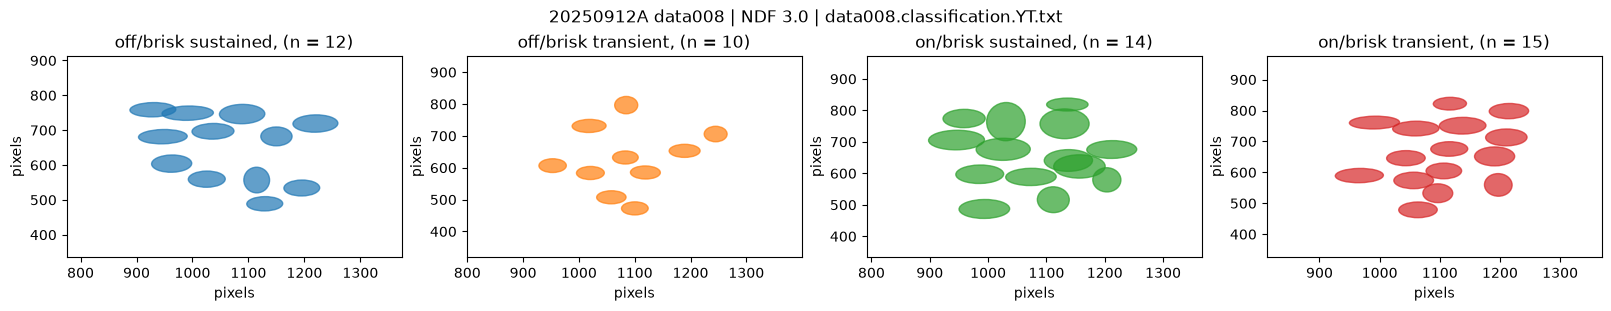

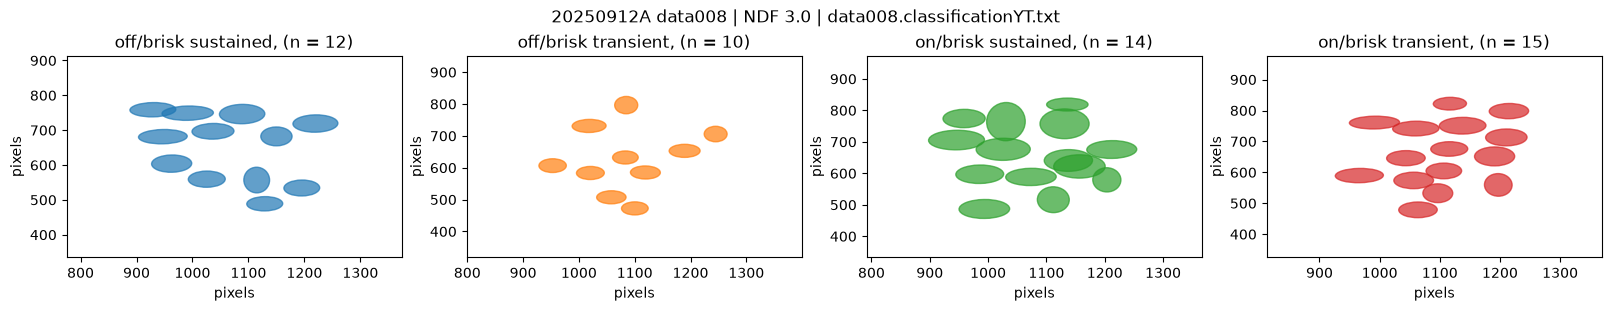

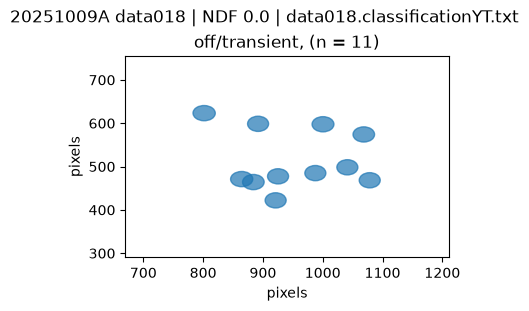

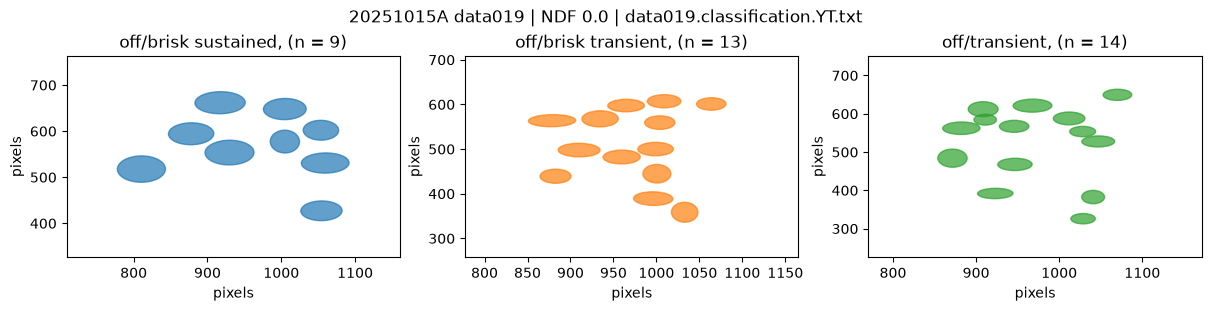

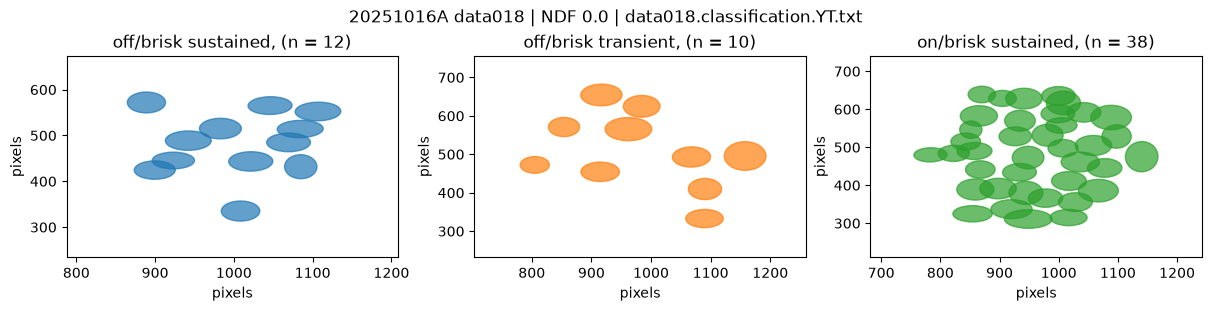

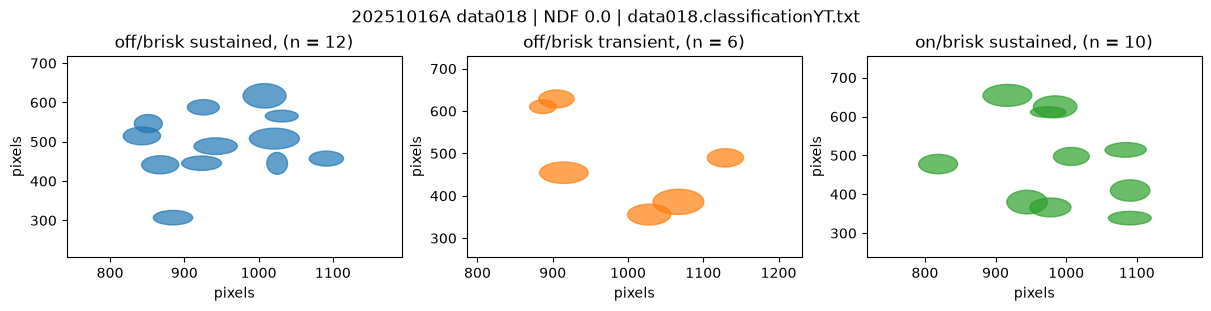

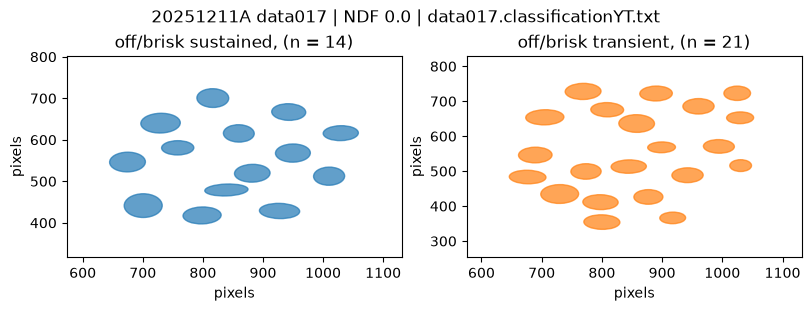

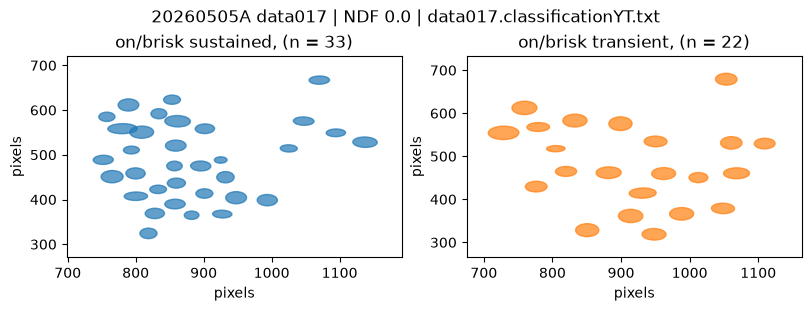

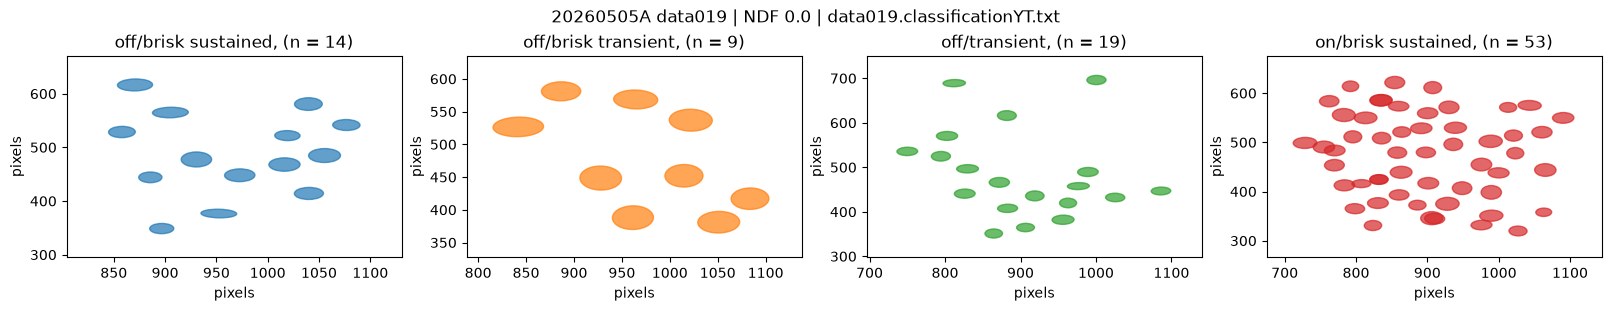

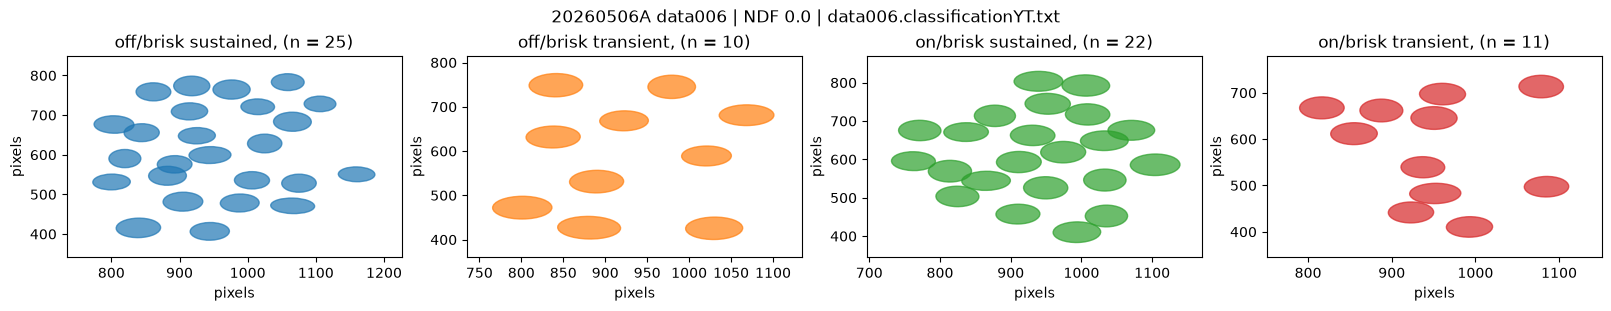

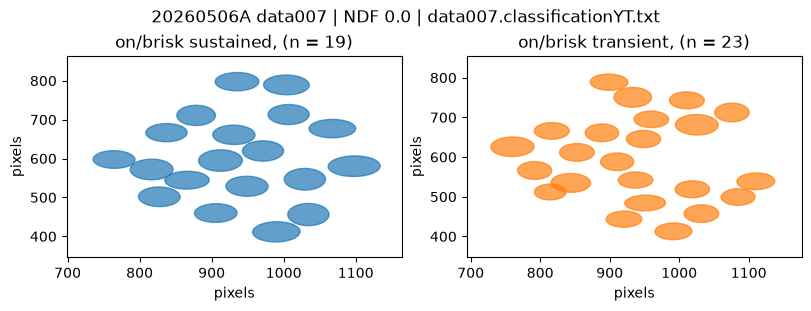

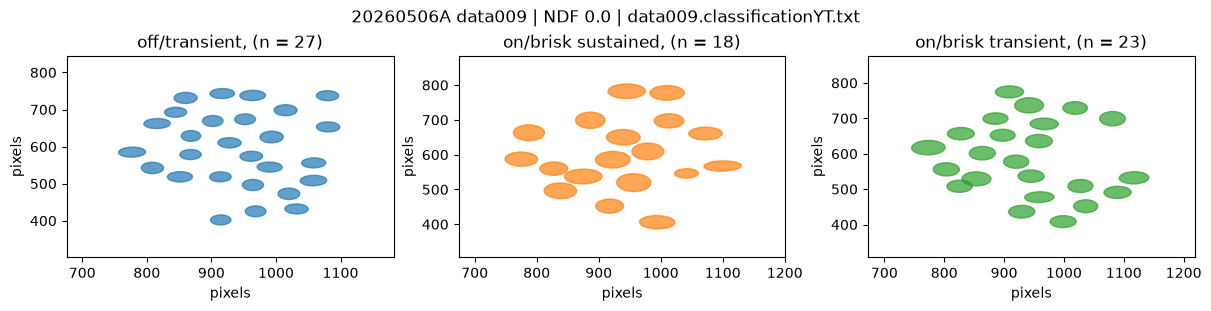

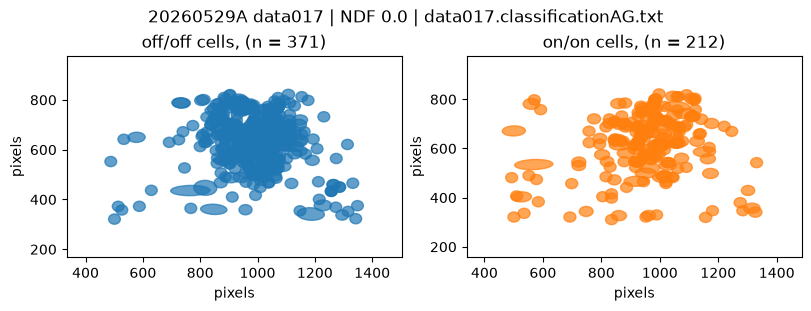

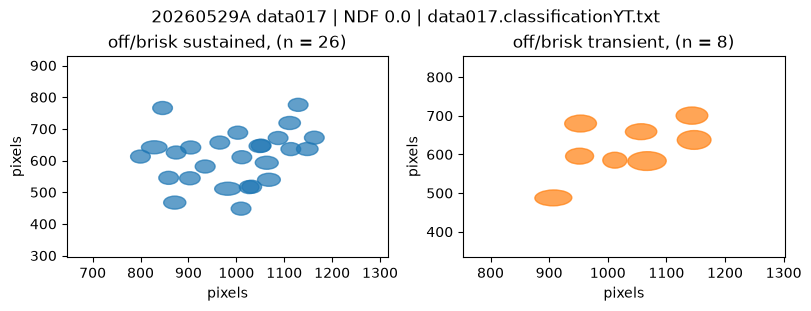

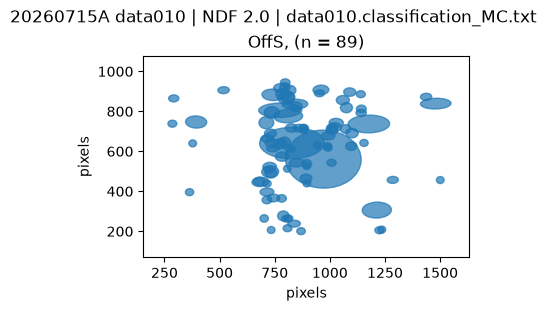

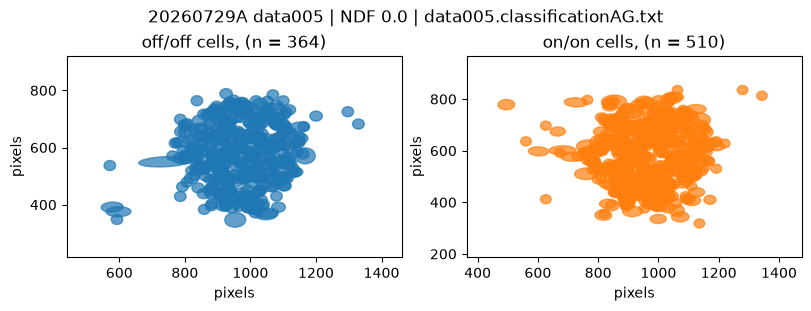

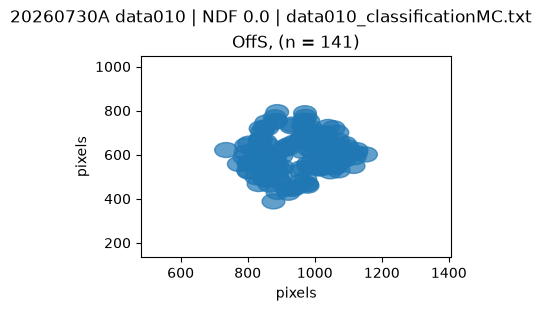

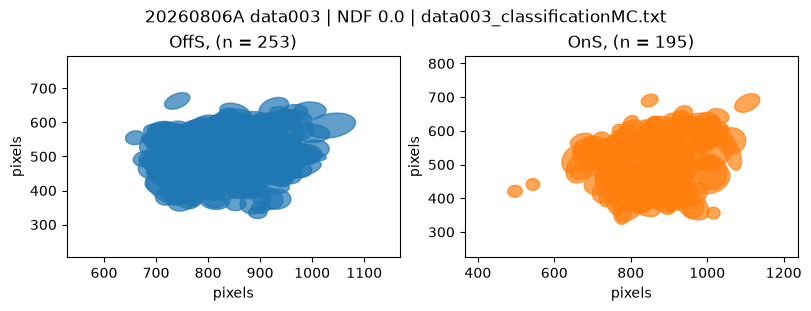

In [5]:
cell_types = None  # None = auto-detect; or e.g. ['on/brisk sustained']
EXCLUDE_CELL_TYPES = ['unknown', 'nc', 'large', 'big', 'huge', 'weak']  # dropped from auto-detected labels

all_axes = ra.plot_mosaics_for_datasets(exp_search, cell_types=cell_types,
                                        exclude_cell_type_keywords=EXCLUDE_CELL_TYPES,
                                        minimum_n=3, b_zoom=True)


## Choose an Experiment

Pick which experiment to analyze and its SpatialNoise datafile (auto-picks the earliest if there are several).

In [ ]:
exp_name = '20260529A'
datafile_name = ra.find_datafile_for_protocol(exp_search, exp_name)

experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary.head())


## Initialize Analysis Pipeline

Builds the MEA pipeline for this datafile, auto-picking a classified white-noise chunk for cell typing unless you set `MANUAL_ANALYSIS_CHUNK`.

In [ ]:
PREFERRED_TYPING_FILE = None  # e.g. 'data007.classificationYT.txt' -- None auto-picks the first one found
MANUAL_ANALYSIS_CHUNK = None  # e.g. 'data001' -- set to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)

with ra.scrollable_prints():
    pipeline = ra.create_mea_pipeline(
        exp_name, datafile_name, analysis_chunk_name=analysis_chunk_name, typing_file=PREFERRED_TYPING_FILE,
    )


## Break Out Underlying Objects

Splits the pipeline into its stimulus, response, and analysis-chunk objects for direct use below.

In [ ]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## Show Stim Information

Looks at the raw per-epoch stimulus table and pulls out block-level parameters -- including the space-constant/stixel-size values, which this dataset stores as `stixelSizes` rather than `spaceConstants`.

In [ ]:
stimulus_data = stim_block.df_epochs
display(stimulus_data)

epoch_block_params = stim_block.d_epoch_block_params
all_space_constants = epoch_block_params['stixelSizes']
space_constant = stimulus_data['epoch_parameters'].apply(
    lambda x: x['stixelSize']
).values


Peek at the raw `epoch_parameters` dict for the first epoch, to see exactly what fields are available.

In [ ]:
stimulus_data['epoch_parameters'].iloc[0]
